In [37]:
# Install des packages 
install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", "caret", "randomForest", "lmtest", "car", "ggrepel", "scales", "viridis", "outliers", "glmnet", "dplyr", "rlang"))

Installation des packages dans ‘/home/ymokhtar/R/x86_64-pc-linux-gnu-library/4.3’
(car ‘lib’ n'est pas spécifié)

Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘corrplot’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘caret’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘randomForest’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘lmtest’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘glmnet’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR",

In [1]:
install.packages("ggplot2")

Installation du package dans ‘/home/ymokhtar/R/x86_64-pc-linux-gnu-library/4.3’
(car ‘lib’ n'est pas spécifié)



In [2]:

library(tidyverse)
library(FactoMineR)
library(factoextra)
library(corrplot)
library(caret)
library(randomForest)
library(lmtest)
library(car)
library(ggrepel)
library(scales)
library(viridis)
library(outliers)
library(glmnet)
library(dplyr)
library(corrplot)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

corrplot 0.95 loaded

Le chargement a nécessité le package : lattice


Attachement du package : ‘caret’


L'objet suivant est masqué depuis ‘package:purrr’:

    lift


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : ‘randomForest’


L'objet suivant e

# Quels sont les facteurs associés au succès commercial d'un jeu ?

## Définir le succès commercial

In [3]:
df <- read_csv("clean.csv")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 113121 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Name, Release date, Estimated owners, Supported languages, Full au...
dbl (23): AppID, Peak CCU, Required age, Price, Discount, DLC count, Reviews...
lgl  (4): Windows, Mac, Linux, Score rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Transformations des features du dataset pour préparer notre variable success_score

In [4]:
df_clean <- df %>%

  select(-`Score rank`, -`User score`) %>%
  
  
  mutate(
    total_reviews = ifelse(`Ratio positive vote` > 0 & !is.na(`Ratio positive vote`),
                           round(Positive / `Ratio positive vote`),
                           Positive),  # si ratio NA, on a 0 négatifs
    Negative = total_reviews - Positive
  ) %>%
  
  # mediane des owners pour tout le monde
  mutate(
    owners_low  = as.numeric(str_extract(`Estimated owners`, "^[0-9]+")),
    owners_high = as.numeric(str_extract(`Estimated owners`, "[0-9]+$")),
    owners_midpoint = (owners_low + owners_high) / 2
  ) %>%
  
  
  mutate(
    nb_languages = str_count(`Supported languages`, ",") + 1
  ) %>%
  
  
  mutate(
    log_owners          = log1p(owners_midpoint),
    log_recommendations = log1p(Recommendations),
    log_peak_ccu        = log1p(`Peak CCU`),
    log_median_playtime = log1p(`Median playtime forever`)
  )

### Évaluation de la fiabilité des ratings avec le Wilson Score

In [5]:
wilson_score <- function(positive, negative, z = 1.96) {
  n <- positive + negative
  if (n == 0) return(NA)
  p_hat <- positive / n
  numerator   <- p_hat + z^2/(2*n) - z * sqrt(p_hat*(1-p_hat)/n + z^2/(4*n^2))
  denominator <- 1 + z^2/n
  return(numerator / denominator)
}

df_clean <- df_clean %>%
  mutate(
    wilson = mapply(wilson_score, Positive, Negative)
  )

### Création de la variable sucess_score

In [6]:
df_clean <- df_clean %>%
  mutate(
    success_score = 0.5 * log_owners +
                    0.3 * log_recommendations +
                    0.2 * wilson
  )

Visualisation de la distribution du score de succès commercial selon les jeux

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_bin()`).”


[1] 1493

Name,success_score,log_owners,log_recommendations,wilson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Counter-Strike 2,14.20355,18.82615,15.39045,0.8667080
PUBG: BATTLEGROUNDS,13.84493,18.82615,14.37699,0.5938040
Grand Theft Auto V Legacy,13.57113,18.13300,14.43300,0.8736560
Black Myth: Wukong,13.36022,18.13300,13.66820,0.9663009
Left 4 Dead 2,13.32811,18.13300,13.55535,0.9750388
Palworld,13.07861,18.13300,12.74684,0.9402968
Terraria,13.07030,17.37086,13.96652,0.9745576
Tom Clancy's Rainbow Six® Siege X,13.05828,17.37086,14.01752,0.8379904
Call of Duty®,13.05575,18.13300,12.90656,0.5864306


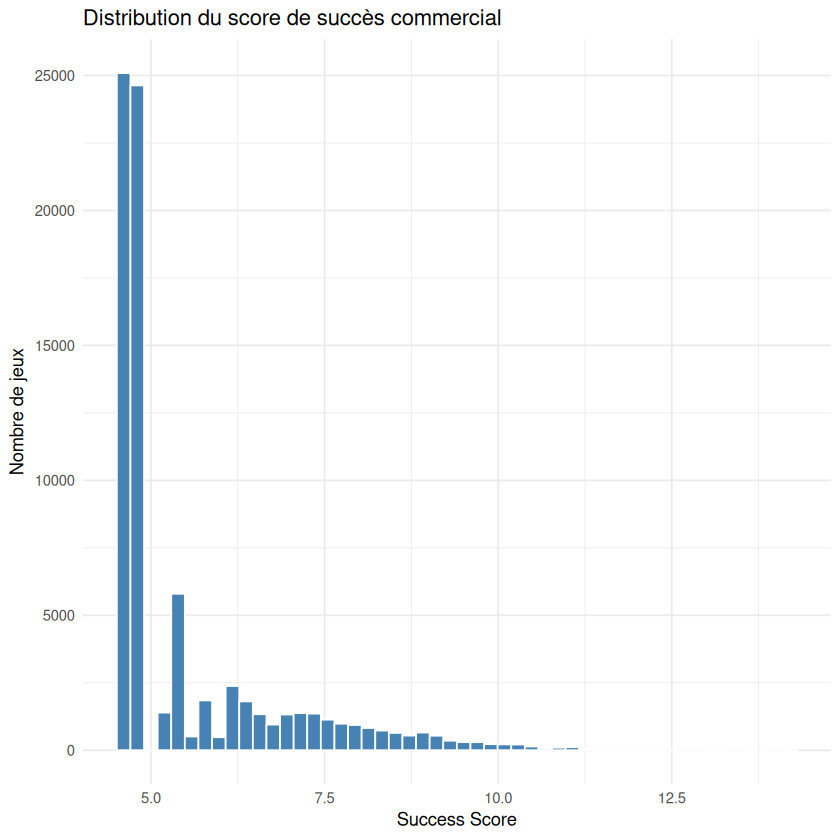

In [7]:
ggplot(df_clean, aes(x = success_score)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  labs(title = "Distribution du score de succès commercial",
       x = "Success Score", y = "Nombre de jeux") +
  theme_minimal()

# idd les outliers 
df_clean <- df_clean %>%
  mutate(
    success_zscore = scale(success_score)[,1],
    is_outlier = abs(success_zscore) > 3
  )

# combien d'outliers 
sum(df_clean$is_outlier, na.rm = TRUE)

df_clean %>%
  filter(is_outlier) %>%
  select(Name, success_score, log_owners, log_recommendations, wilson) %>%
  arrange(desc(success_score)) %>%
  head(20)


Score pour Jusant par exemple (bon score qui reflète un bon succès en réalité bien que le jeu soit indie et possède bien moins de joueurs qu'un AAA) le score le prend en compte. 

In [8]:
df_clean %>%
  filter(str_detect(Name, "Jusant")) %>%
  select(Name, success_score, log_owners, log_recommendations, 
         wilson, owners_midpoint, Positive, Negative)

Name,success_score,log_owners,log_recommendations,wilson,owners_midpoint,Positive,Negative
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jusant,9.02752,12.76569,8.200014,0.9233531,350000,4649,346


# Quels facteurs sont associés au succès commercial
### Visualisation des corrélations entre variables avec un corrplot afin pour avoir une première idée des relations avec le succès commercial.

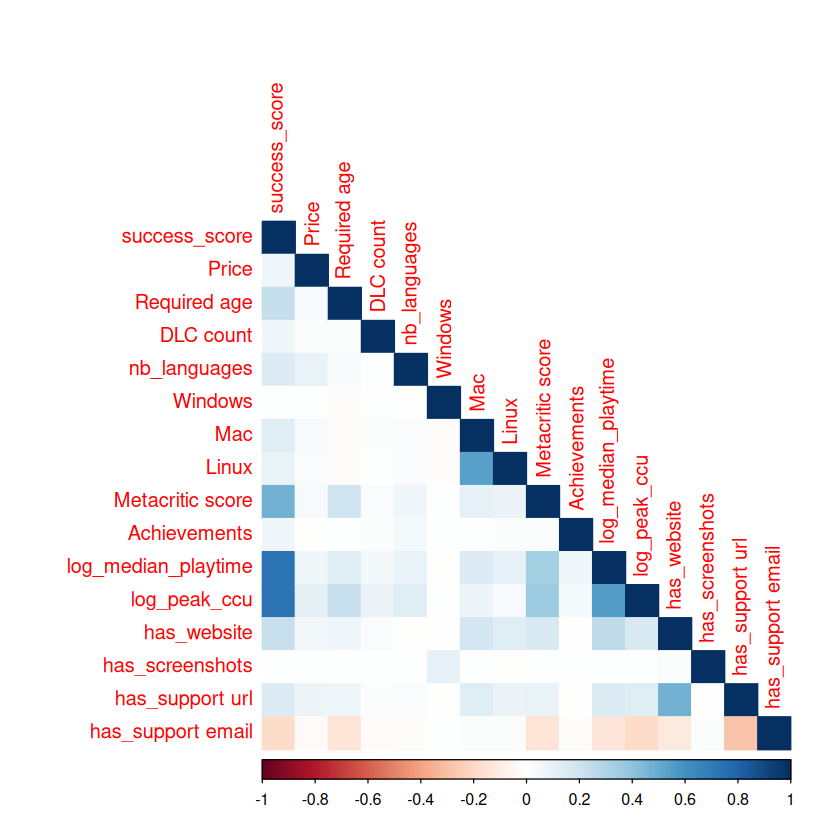

In [11]:
cor_matrix <- cor(data_model)
corrplot(cor_matrix, method = "color", type = "lower")

### Modèle LASSO plus robuste pour déterminer ces facteurs

                       lambda.min
log_peak_ccu         0.4662388923
log_median_playtime  0.2379539404
Windows              0.1184826362
has_screenshots      0.0854318195
has_support email   -0.0829453654
Linux                0.0465230974
Mac                  0.0356853542
Required age         0.0310955143
has_website          0.0275452355
Metacritic score     0.0135244098
has_support url     -0.0133258459
nb_languages         0.0041624088
Price               -0.0025456212
Achievements         0.0001334702
DLC count            0.0000000000


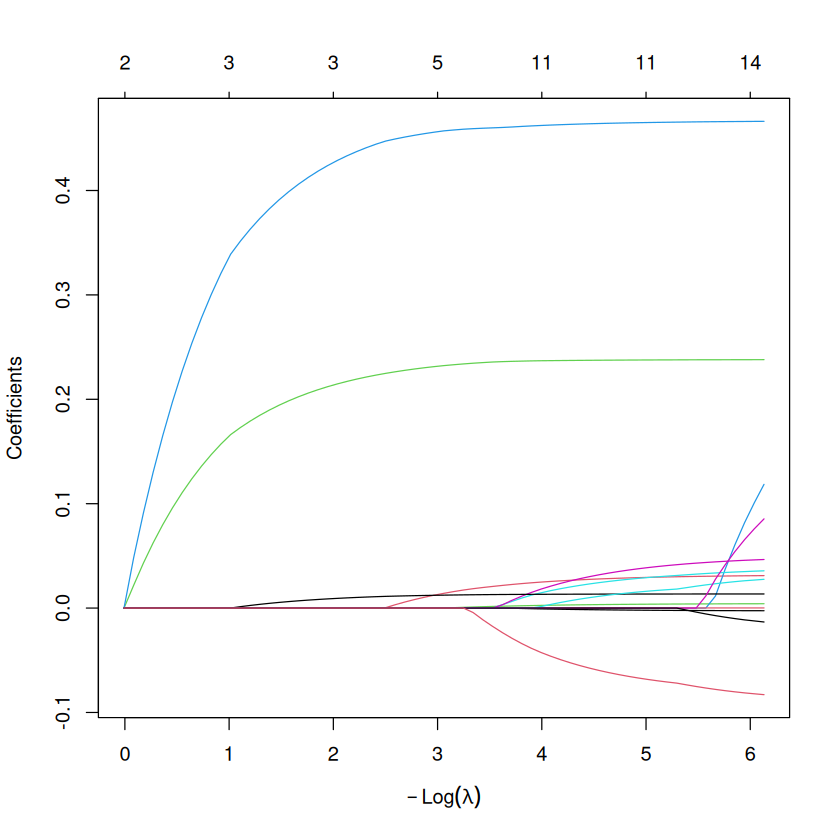

In [10]:
data_model <- df_clean %>%
  select(
    success_score,
    Price, `Required age`, `DLC count`,
    nb_languages, Windows, Mac, Linux,
    `Metacritic score`, Achievements,
    log_median_playtime, log_peak_ccu,
    has_website, has_screenshots,
    `has_support url`, `has_support email`
  ) %>%
  mutate(across(where(is.logical), as.numeric)) %>%
  drop_na()

X <- data.matrix(data_model %>% select(-success_score))
y <- data_model$success_score
set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,        # LASSO
  standardize = TRUE
)

set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,
  standardize = TRUE
)

plot(lasso_cv$glmnet.fit, xvar = "lambda")

coef_lasso <- coef(lasso_cv, s = "lambda.min")




important_vars <- coef_lasso[-1, , drop = FALSE]  # enlever l'intercept
important_vars <- as.matrix(important_vars)
important_vars <- important_vars[order(abs(important_vars[,1]), decreasing = TRUE), , drop = FALSE]


print(important_vars)

## Analyse de ces facteurs 

### DLC Count (facteur décidés par les devs, pas capturé par le LASSO)
Motivation d'étudier le DLC Count : 
DLC count à 0 dans LASSO  :  redondance avec log_peak_ccu (c'est pas une question de causalité)

DLC count comme indicateur : causalité ou conséquences de succès préalable ? (que le LASSO ne peut pas voir)


	Wilcoxon rank sum test with continuity correction

data:  log_owners by has_dlc
W = 607334130, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by has_dlc
W = 257778151, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by has_dlc
W = 541872292, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


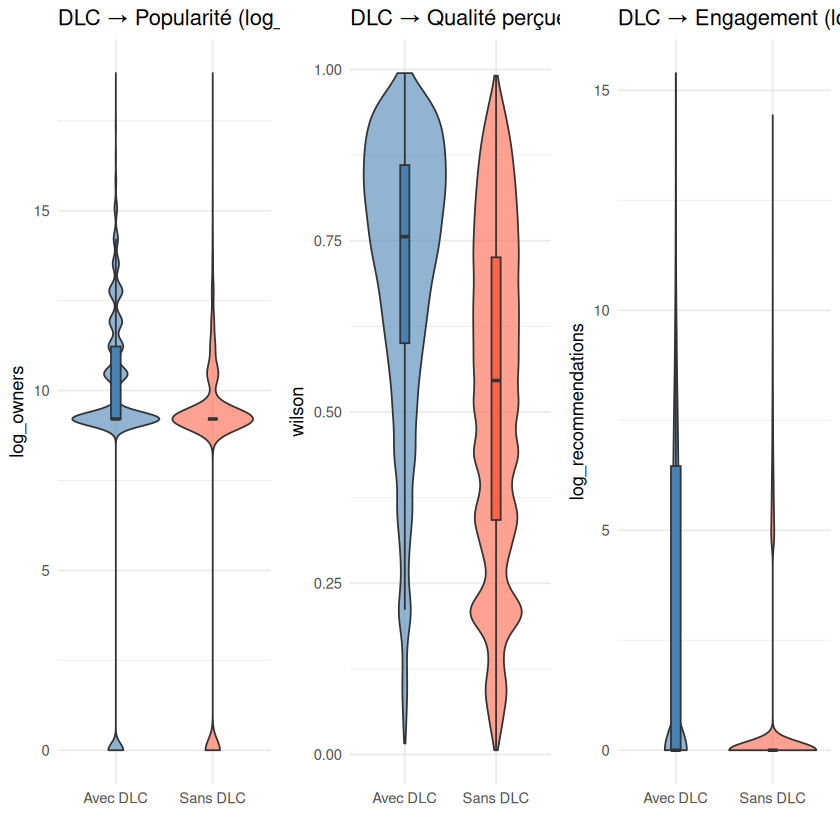

In [12]:
df_analysis <- df_clean %>%
  mutate(
    has_dlc = `DLC count` > 0,
    price_group = case_when(
      Price == 0 ~ "Gratuit",
      Price < 5  ~ "< 5e",
      Price < 15 ~ "5-15e",
      Price < 30 ~ "15-30e",
      TRUE       ~ "> 30e"
    ) %>% factor(levels = c("Gratuit", "< 5e", "5-15e", "15-30e", "> 30e"))
  )

plot_binary_vs_success <- function(data, binary_var, success_var, 
                                    label_true, label_false, title) {
  data %>%
    filter(!is.na(.data[[success_var]]), !is.na(.data[[binary_var]])) %>%
    mutate(group = ifelse(.data[[binary_var]], label_true, label_false)) %>%
    ggplot(aes(x = group, y = .data[[success_var]], fill = group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_manual(values = c("steelblue", "tomato")) +
    labs(title = title, x = "", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none") 
}

p1a <- plot_binary_vs_success(df_analysis, "has_dlc", "log_owners",
                               "Avec DLC", "Sans DLC",
                               "DLC → Popularité (log_owners)")
p1b <- plot_binary_vs_success(df_analysis, "has_dlc", "wilson",
                               "Avec DLC", "Sans DLC",
                               "DLC → Qualité perçue (wilson)")
p1c <- plot_binary_vs_success(df_analysis, "has_dlc", "log_recommendations",
                               "Avec DLC", "Sans DLC",
                               "DLC → Engagement (log_recommendations)")

gridExtra::grid.arrange(p1a, p1b, p1c, ncol = 3)

# Tests statistiques
wilcox.test(log_owners ~ has_dlc, data = df_analysis)
wilcox.test(wilson ~ has_dlc, data = df_analysis)
wilcox.test(log_recommendations ~ has_dlc, data = df_analysis)

La présence de DLC est significativement associée aux trois composantes du succès (p < 2.2e-16). L'effet le plus marqué concerne la qualité perçue, les jeux avec DLC affichent un Wilson Score plus élevé et moins dispersé, laisse penser qu'ils proviennent de studios plus établis produisant des jeux mieux reçus. Cet effet est probablement indirect : Les jeux a succès font des DLC pour profiter encore plus de ce succès plutôt que les jeux font succès car ils possèdent un DLC, c'est un lien de causalité inversé.

## Prix



	Kruskal-Wallis rank sum test

data:  log_owners by price_group
Kruskal-Wallis chi-squared = 6138.7, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  wilson by price_group
Kruskal-Wallis chi-squared = 1399.4, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  log_recommendations by price_group
Kruskal-Wallis chi-squared = 6119.6, df = 4, p-value < 2.2e-16


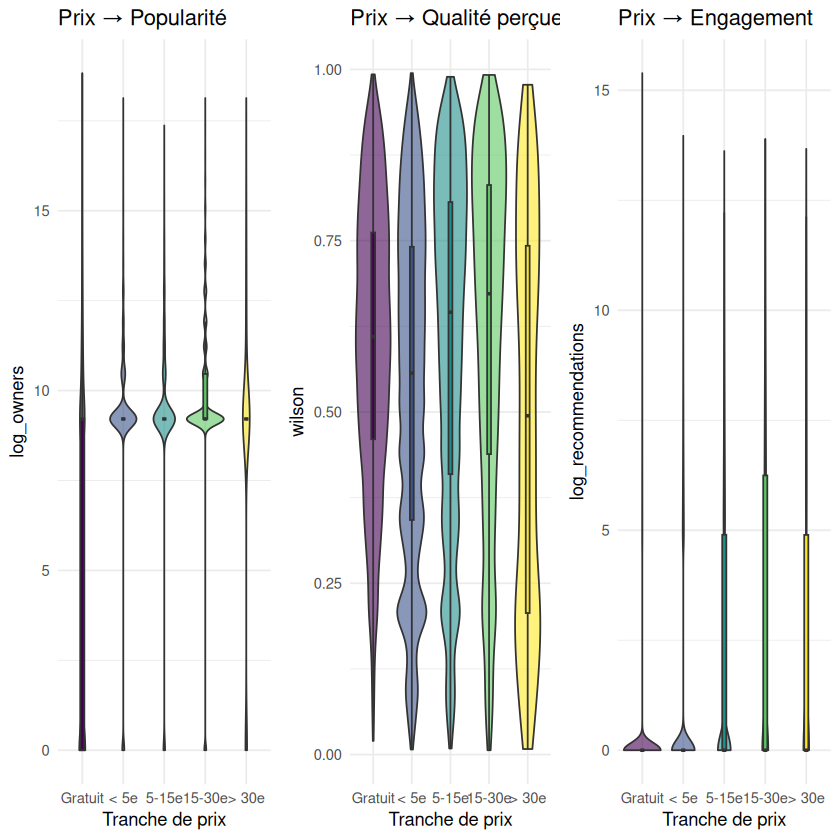

In [14]:
# Visualisation par groupe de prix
plot_price <- function(success_var, title) {
  df_analysis %>%
    filter(!is.na(.data[[success_var]])) %>%
    ggplot(aes(x = price_group, y = .data[[success_var]], fill = price_group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_viridis_d() +
    labs(title = title, x = "Tranche de prix", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none")
}

p2a <- plot_price("log_owners", "Prix → Popularité")
p2b <- plot_price("wilson", "Prix → Qualité perçue")
p2c <- plot_price("log_recommendations", "Prix → Engagement")

gridExtra::grid.arrange(p2a, p2b, p2c, ncol = 3)

# Test Kruskal-Wallis (variable catégorielle)
kruskal.test(log_owners ~ price_group, data = df_analysis)
kruskal.test(wilson ~ price_group, data = df_analysis)
kruskal.test(log_recommendations ~ price_group, data = df_analysis)